### note
<br/>

### note name

In [1]:
# pip install ipynbname

import ipynbname
nb_name = ipynbname.name()
nb_path = ipynbname.path()

nb_name

'2Samples Classical_GRU_P11 SEEDs_ini_2'

## Hyper parameters

In [2]:
SEED = 2
# SEEDs = range(10) # 0~9
L_RATE = 0.2 # 0.2
N_STEPS = 1000000
NUM_SEEDs = 50

In [3]:
from jax.config import config
config.update("jax_enable_x64", True)

import jax
import jax.numpy as jnp
import pennylane as qml
from jax.example_libraries import optimizers
from jax.example_libraries import stax
from jax import value_and_grad
from jax import lax

import optax
# from functools import partial
import time
import matplotlib.pyplot as plt
import pickle


from SQGRU_j7x import SQGRU, qgru
from Classical_RNN import simple_rnn, gru, count_parameters

### force to use cpu

In [4]:
jax.config.update('jax_platform_name', 'cpu')

In [5]:
qml.version()

'0.31.1'

## Oscillations

In [6]:
def damped_shm(fre, damp):
    amp = 0.7
    num_data = 151
    x = jnp.array(range(num_data))
    y = jnp.sin(x*fre)*jnp.exp(x*damp)*amp

    return y

In [7]:
osc1 = damped_shm(0.4, 0)
osc2 = damped_shm(0.6, -0.02)

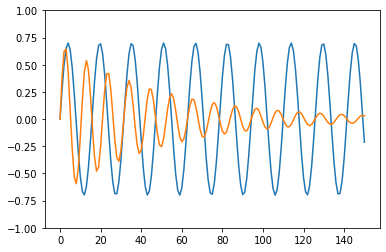

In [8]:
plt.plot(osc1)
plt.plot(osc2)
plt.ylim(-1,1)
plt.show()

In [9]:
oscillations = jnp.array([osc1,osc2])
true_data = jnp.expand_dims(oscillations, 2)
train_input = true_data[:,0:100,:]
train_target = true_data[:,1:101,:]

## Model
### Hyper parameters

In [10]:
# model parameters
OUT_DIM = 1

In [11]:
init_fun, qgru_rnn = stax.serial(gru(OUT_DIM, sequence_out=True), stax.Dense(1))

In [12]:
key = jax.random.PRNGKey(SEED)
key1, key2 = jax.random.split(key, num=2)
_, params = init_fun(key1, jnp.shape(train_input))

In [13]:
count_parameters(params)

11

## Train

In [14]:
step_size = L_RATE
optimizer = optax.adam(step_size)
opt_state = optimizer.init(params)

In [15]:

@jax.jit
def loss_fn(params, xs, ys):
#     prediction = qgru_rnn(params, xs)[:,:,0:1]
    prediction = qgru_rnn(params, xs)
#     prediction = cls_predict(xs, 10, params)
    
    return jnp.mean((prediction - ys)**2) # the prediction shape


# def update(i_step, params, xs, ys, opt_state):
#     loss, grads = value_and_grad(loss_fn)(params, xs, ys)
#     updates, opt_state = optimizer.update(grads, opt_state)
#     params = optax.apply_updates(params, updates)
#     return params, opt_state, loss


In [16]:
minLoss = 1000
best_params = params
lossList = []
loc_params_list = []
reset_steps = []

In [17]:
def ck_lr(old_lr, new_lr):
    d_lr = old_lr - new_lr
    return d_lr >= 0 and d_lr/new_lr < 1e-2

### prediction

In [18]:
_, qgru_rnn2 = stax.serial(gru(OUT_DIM, sequence_out=True), stax.Dense(1))

In [19]:
@jax.jit
def jit_rnn(params, inputs):
    return qgru_rnn2(params, inputs)

In [20]:
true1 = true_data.squeeze()[:,0:100]
true2 = true_data.squeeze()[:,100:]
xs = train_input

In [21]:
# for classical rnn to predict the trend
def cls_predict(inp, pred_length, params):
    ys = jit_rnn(params, inp)
    new_inp = inp
    for _ in range(pred_length-1):
        new_inp = jnp.concatenate([new_inp, ys[:,-1:]], axis=1)
        ys = jit_rnn(params, new_inp)
    return ys

### start

In [22]:
update_lr = True
lr_factor = 1
locLossList = [1000,1000,1000]
locLoss = 1000
loc_params = params



start = time.time()
for i in range(N_STEPS):
    
    if update_lr != 0:
        if update_lr < 0:
            params = loc_params
        else:
            locLossList = [1000,1000,1000]
            locLoss = 1000
            loc_params_list.append(loc_params)
            reset_steps.append(i)
            # reset parameters
            key1, key2 = jax.random.split(key2, num=2)
            _, params = init_fun(key1, jnp.shape(train_input))
            loc_params = params
            # stop when collect X local best parameters
            if len(loc_params_list) > NUM_SEEDs:
                break
        update_lr = 0
            
        # update learning rate
        optimizer = optax.adam(step_size)
        opt_state = optimizer.init(params)
        
        print('learning rate:', step_size)

        def update(i_step, params, xs, ys, opt_state):
            loss, grads = value_and_grad(loss_fn)(params, xs, ys)
            updates, opt_state = optimizer.update(grads, opt_state)
            params = optax.apply_updates(params, updates)
            return params, opt_state, loss
    
    pre_params = params
    params, opt_state, loss = update(i, params, train_input, train_target, opt_state)
    print('{}: {}   {} sec      '.format(i, loss, time.time()-start), end='\r')
    if loss < minLoss:
        best_params = pre_params
        minLoss = loss
    if loss < locLoss:
        loc_params = pre_params
        locLoss = loss
    if (i+1) % 100 == 0:
        # update learning rate?
        if loss > locLossList[0] and locLossList[1] > locLossList[0] and locLossList[2] > locLossList[0]:
            step_size /= 2
            update_lr = -1
        elif ck_lr(locLossList[2], loss) and ck_lr(locLossList[1], locLossList[2]) and ck_lr(locLossList[0], locLossList[1]):
            # reset
            step_size = L_RATE
            update_lr = 1
        locLossList[0] = locLossList[1]
        locLossList[1] = locLossList[2]
        locLossList[2] = loss
        
        
        lossList.append(loss)
        print('{}: {}   {} sec      '.format(i, loss, time.time()-start))

learning rate: 0.2
99: 0.0077745624531771074   1.3405296802520752 sec      
199: 0.012285943534905376   2.0793488025665283 sec       
299: 0.008065232612388304   2.7992846965789795 sec       
399: 0.008365887611810337   3.590925455093384 sec        
learning rate: 0.1
499: 0.007695962848561886   4.396709680557251 sec        
599: 0.009551506987186193   5.200606822967529 sec        
699: 0.007814913881858693   6.009462594985962 sec       
799: 0.012466743192281424   6.801730155944824 sec        
learning rate: 0.05
899: 0.008496595433233443   7.498926639556885 sec        
999: 0.00839688027513564   8.28507137298584 sec         
learning rate: 0.025
1099: 0.007587590220560849   9.044116735458374 sec       
1199: 0.007286570983452774   9.826439619064331 sec       
1299: 0.007580476991934188   10.584961891174316 sec       
1399: 0.008845163117877315   11.35668420791626 sec        
1499: 0.007518116732858448   12.121721029281616 sec       
learning rate: 0.0125
1599: 0.007580214585453662   

25799: 0.007646046498119197   183.40737509727478 sec       
25899: 0.007545973936086401   184.09845614433289 sec       
25999: 0.007755504433991616   184.7797348499298 sec        
26099: 0.007609651279314706   185.48795247077942 sec       
26199: 0.007653623633024503   186.16017413139343 sec       
learning rate: 0.05
26299: 0.007791929367657277   186.8441390991211 sec        
26399: 0.0074686483785581445   187.55191588401794 sec      
26499: 0.007508873465968311   188.25561547279358 sec       
26599: 0.008054632120149945   188.94753408432007 sec       
26699: 0.007450280581272195   189.63581490516663 sec       
26799: 0.007837896381013213   190.33497095108032 sec       
26899: 0.008603429598077498   191.02600598335266 sec       
26999: 0.007674437378813082   191.74886989593506 sec      
learning rate: 0.025
27099: 0.007337731208272656   192.51723456382751 sec       
27199: 0.007962611404602516   193.2489457130432 sec        
27299: 0.007560116395129419   193.9739065170288 sec        


51299: 0.007239750814466293   366.0184061527252 sec        
51399: 0.007331276587795228   366.7871673107147 sec        
51499: 0.007456349923941566   367.52266120910645 sec       
learning rate: 0.0015625
51599: 0.007284770494464377   368.30251455307007 sec       
learning rate: 0.00078125
51699: 0.007241766934121817   369.03262162208557 sec       
51799: 0.007224977135945451   369.763968706131 sec         
51899: 0.00722296249764498   370.4858229160309 sec         
learning rate: 0.2
51999: 0.011837156844389199   371.22128558158875 sec      
52099: 0.008136200131462431   371.9789435863495 sec       
52199: 0.007778722680163874   372.7024829387665 sec       
52299: 0.012675523787877419   373.4284906387329 sec       
52399: 0.008558974870560102   374.1773452758789 sec       
52499: 0.007874384183487041   374.9092307090759 sec       
learning rate: 0.1
52599: 0.00824050722867127   375.67438316345215 sec        
52699: 0.00755779581634407   376.4100248813629 sec         
52799: 0.00757243

76799: 0.007184653841671851   555.2360737323761 sec       
76899: 0.007148804675854068   555.9717264175415 sec       
learning rate: 0.003125
76999: 0.007136468199686168   556.7032096385956 sec       
77099: 0.007116306215308712   557.4411232471466 sec       
learning rate: 0.2
77199: 0.008798985538110888   558.1976270675659 sec      
77299: 0.012283343917468048   558.9354672431946 sec       
77399: 0.017649145625067128   559.6910951137543 sec       
77499: 0.008381528515906074   560.4111664295197 sec       
77599: 0.009518638377487003   561.1346044540405 sec       
77699: 0.011428394718461018   561.8692734241486 sec      
77799: 0.0076487080432191545   562.6207084655762 sec      
77899: 0.013088655364203871   563.3558559417725 sec       
77999: 0.02596763207700279   564.1324670314789 sec        
78099: 0.013843256697141839   564.8579339981079 sec      
learning rate: 0.1
78199: 0.008986799392268598   565.5925126075745 sec       
78299: 0.007902239427175745   566.4676280021667 sec     

102499: 0.0081398251189553   745.7699718475342 sec        
learning rate: 0.0125
102599: 0.007714890766768282   746.5149006843567 sec      
102699: 0.007475801761710743   747.2851052284241 sec       
102799: 0.007468797213060718   748.0429122447968 sec       
102899: 0.007823006351086627   748.834802865982 sec        
102999: 0.007419584971174691   749.5757265090942 sec       
103099: 0.007794567576548607   750.3702282905579 sec       
103199: 0.007945649637209298   751.1201138496399 sec       
103299: 0.00754548298186196   751.8720910549164 sec        
learning rate: 0.00625
103399: 0.007608182044641298   752.7429411411285 sec       
103499: 0.00746814886630095   753.528781414032 sec         
103599: 0.007330807489896652   754.2902207374573 sec       
103699: 0.007357586925818436   755.0454647541046 sec       
103799: 0.007495764224255883   755.8175740242004 sec       
103899: 0.007575406002311812   756.5925419330597 sec       
learning rate: 0.003125
103999: 0.007376231761649011   75

127999: 0.007556467787416781   973.5840499401093 sec       
learning rate: 0.00625
128099: 0.007428398981184399   974.5615124702454 sec       
128199: 0.007341851332860157   975.4996149539948 sec       
128299: 0.007481478445471097   976.4064972400665 sec       
128399: 0.007640398997889504   977.3042979240417 sec       
128499: 0.007732093739825734   978.3899891376495 sec       
learning rate: 0.003125
128599: 0.007368105841565016   979.3988881111145 sec       
128699: 0.007244238135785559   980.3140161037445 sec       
128799: 0.007263454861874426   981.172073841095 sec        
128899: 0.007304222871036634   982.2370054721832 sec       
128999: 0.007407741137280412   983.3373122215271 sec       
learning rate: 0.0015625
129099: 0.007286702302257478   984.3200979232788 sec       
learning rate: 0.00078125
129199: 0.007244960523858146   985.2395489215851 sec       
129299: 0.007228246634106976   986.1368491649628 sec       
129399: 0.007225234299890723   986.997373342514 sec        
le

153199: 0.007179769987725645   1186.5390496253967 sec       
153299: 0.007167856744500194   1187.3712394237518 sec       
153399: 0.007157056500354908   1188.1739876270294 sec       
learning rate: 0.2
153499: 0.009147449829521414   1189.033434867859 sec       
153599: 0.008047121817538607   1189.8371751308441 sec      
153699: 0.01873897021374384   1190.611788034439 sec        
153799: 0.016003036576273832   1191.3985483646393 sec      
153899: 0.017246191351079704   1192.1830923557281 sec      
learning rate: 0.1
153999: 0.008043525735412982   1192.9868121147156 sec       
154099: 0.007804019223341186   1193.7713248729706 sec       
154199: 0.007616742138470527   1194.5520346164703 sec       
154299: 0.009432945303819612   1195.3514823913574 sec       
154399: 0.007746923084399915   1196.1476390361786 sec       
154499: 0.011445586373771507   1196.9576675891876 sec       
learning rate: 0.05
154599: 0.007730013799367797   1197.7554142475128 sec       
154699: 0.009479199198097593   1

178199: 0.0076364377068645255   1389.143051624298 sec       
178299: 0.007953914248973352   1389.9084537029266 sec       
learning rate: 0.0125
178399: 0.007705608335728098   1390.7260465621948 sec       
learning rate: 0.00625
178499: 0.007533052705507681   1391.5119016170502 sec       
178599: 0.007519725150268948   1392.2964539527893 sec       
178699: 0.007547211819956148   1393.0910031795502 sec       
178799: 0.007485396718807245   1393.8825798034668 sec       
178899: 0.007453869535883922   1394.6800167560577 sec       
178999: 0.007512279627204552   1395.472977399826 sec        
179099: 0.007459961678472833   1396.2607290744781 sec       
179199: 0.007471428991396178   1397.052704334259 sec        
learning rate: 0.003125
179299: 0.0073968321377565595   1397.8562052249908 sec      
179399: 0.007295281256302748   1398.6745262145996 sec       
179499: 0.007364477241859176   1399.466789484024 sec        
179599: 0.007275732783484015   1400.2881455421448 sec       
179699: 0.007274

203199: 0.007397245386192768   1595.6328415870667 sec       
203299: 0.007247180838034668   1596.4562096595764 sec       
203399: 0.007305808281511108   1597.2761974334717 sec       
203499: 0.007389047702224279   1598.1074151992798 sec       
203599: 0.0073603947773578215   1599.0111856460571 sec      
learning rate: 0.0015625
203699: 0.00729058192318694   1599.8178749084473 sec        
203799: 0.0072345644863900365   1600.6621868610382 sec      
learning rate: 0.2
203899: 0.008907705827655422   1601.4905955791473 sec      
203999: 0.007396300929566644   1602.309173822403 sec        
204099: 0.008064978962574736   1603.1576256752014 sec      
204199: 0.012129647053891838   1603.972906112671 sec        
204299: 0.008942251718451859   1604.7974843978882 sec       
learning rate: 0.1
204399: 0.007652069775258781   1605.598270893097 sec        
204499: 0.00846172529421411   1606.429247379303 sec         
204599: 0.015161879398959993   1607.2427468299866 sec       
204699: 0.00776325284524

In [23]:
minLoss

Array(0.00708314, dtype=float64)

In [24]:
# Save
# Loss, minLoss, params, best_params, loc_params_list, reset_steps
with open(nb_name+'_state.pkl', 'wb') as f:
    pickle.dump((lossList, minLoss, params, best_params, loc_params_list, reset_steps), f)

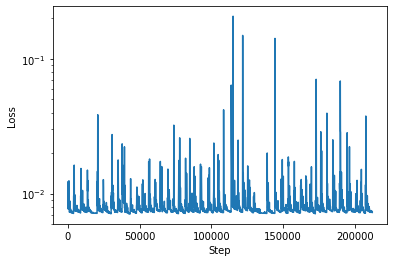

In [25]:
plt.plot([x*100 for x in range(len(lossList))], lossList)
plt.ylabel('Loss')
plt.xlabel('Step')
plt.yscale("log")
plt.show()

## Result

### best parameters

In [26]:
ys = cls_predict(xs, 50, best_params)

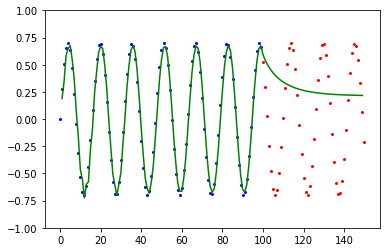

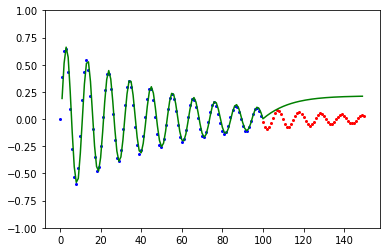

In [27]:
for idx in [0, 1]:
    plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
    plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
    plt.plot(jnp.array(range(len(ys[idx])))+1, ys[idx], c='g')
    plt.ylim(-1,1)
    plt.show()

### final parameters

In [28]:
ys = cls_predict(xs, 50, params)

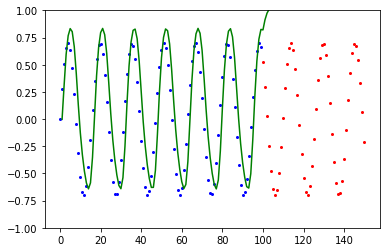

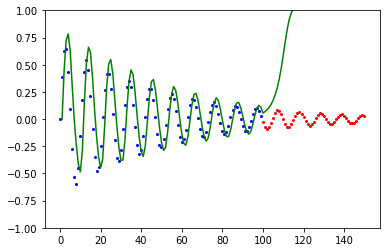

In [29]:
for idx in [0, 1]:
    plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
    plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
    plt.plot(jnp.array(range(len(ys[idx])))+1, ys[idx], c='g')
    plt.ylim(-1,1)
    plt.show()

## Load & find the best parameters

In [22]:
# load
# Loss, minLoss, params, best_params, loc_params_list, reset_steps
with open(nb_name+'_state.pkl', 'rb') as f:
    lossList, minLoss, params, best_params, loc_params_list, reset_steps = pickle.load(f)

In [23]:
test_result = []
min_loss = 1000
k = 0
for i in reset_steps[1:]:
    k += 1
    j = int(i/100 -1)
    i_loss = lossList[j]
    i_params = loc_params_list[k]
    
    ys = cls_predict(xs, 50, i_params)
    
    t_loss = jnp.mean((true2[:,:-1]-ys[:,-50:,0])**2)
    test_result.append([i,i_loss,t_loss,i_params,ys])
    if t_loss < min_loss:
        min_loss = t_loss
        min_idx = k-1
        min_ys = ys
        
test_result[min_idx]

[125200,
 Array(0.00748056, dtype=float64),
 Array(0.14013569, dtype=float64),
 [((Array([[-3.89568638]], dtype=float64),
    Array([[-9.98014029]], dtype=float64),
    Array([0.60263707], dtype=float64)),
   (Array([[4.48491595]], dtype=float64),
    Array([[3.71273365]], dtype=float64),
    Array([1.32583517], dtype=float64)),
   (Array([[-1.32205226]], dtype=float64),
    Array([[-1.39432502]], dtype=float64),
    Array([0.82422496], dtype=float64))),
  (Array([[-1.66746105]], dtype=float64), Array([0.58598355], dtype=float64))],
 Array([[[ 0.18644194],
         [ 0.34466452],
         [ 0.6321199 ],
         [ 0.59381073],
         [ 0.72623507],
         [ 0.50288297],
         [ 0.38826523],
         [ 0.08177401],
         [-0.15489467],
         [-0.42276534],
         [-0.58385234],
         [-0.68233467],
         [-0.65991488],
         [-0.53973646],
         [-0.30633534],
         [-0.04773867],
         [ 0.23367119],
         [ 0.44134393],
         [ 0.61915608],
     

In [24]:
# Save results
# [[i,i_loss,t_loss,i_params,ys]...]
with open(nb_name+'_test_result.pkl', 'wb') as f:
    pickle.dump(test_result, f)

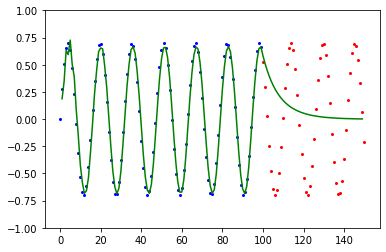

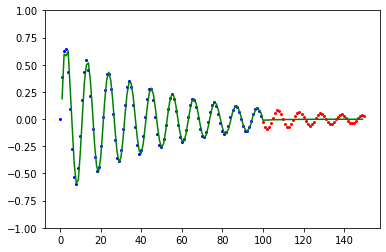

In [32]:
for idx in [0, 1]:
    plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
    plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
    plt.plot(jnp.array(range(len(min_ys[idx])))+1, min_ys[idx], c='g')
    plt.ylim(-1,1)
    plt.show()

best: [125200, Array(0.00748056, dtype=float64), Array(0.14013569, dtype=float64)]
4000 0.007141465266168041 0.17154349703602603


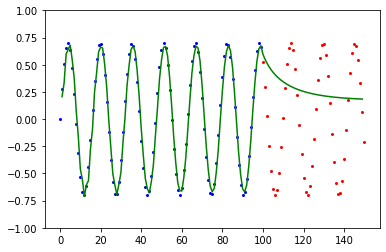

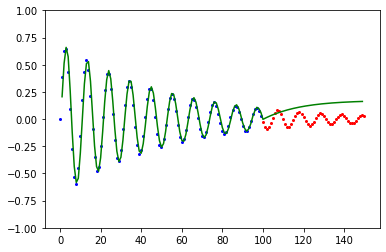

8900 0.007209253904082375 0.18273383400727208


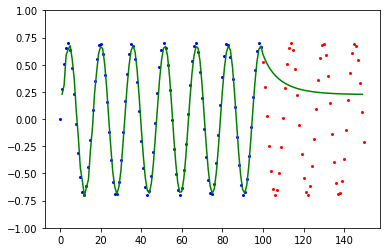

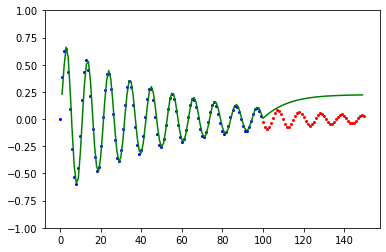

13300 0.0072669519086003545 0.16117905992826373


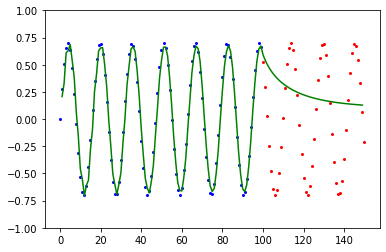

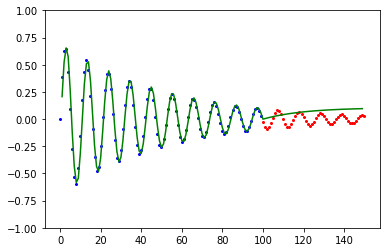

20400 0.007153405738352538 0.16847987538624884


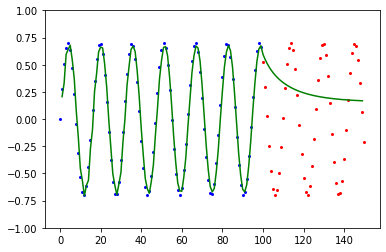

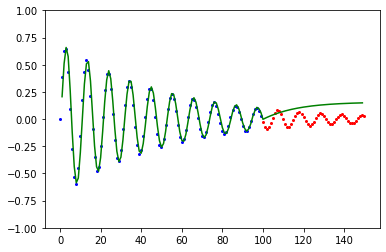

24500 0.007253234856326878 0.16118639151615352


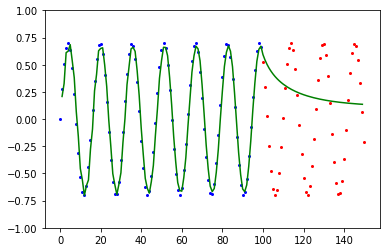

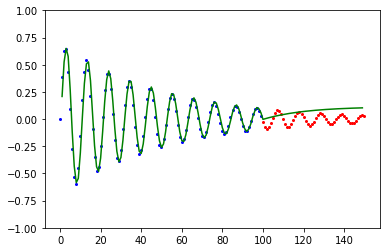

30200 0.007114153038359897 0.18605396712864103


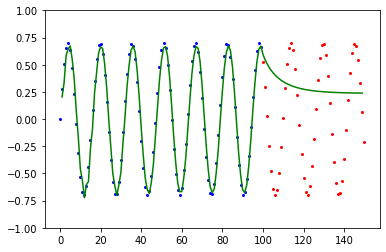

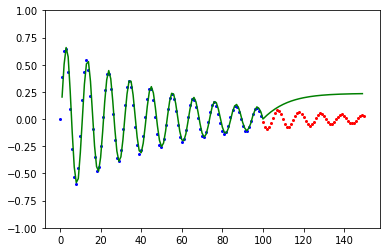

34700 0.00725822126201211 0.16097438223664026


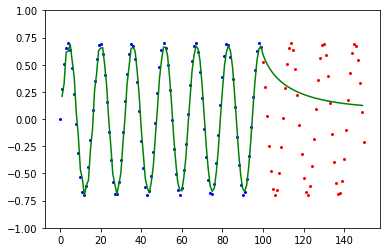

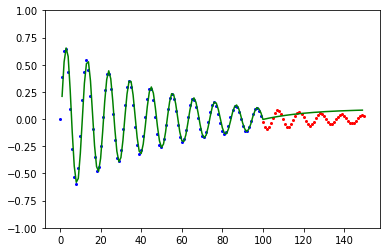

37800 0.0073118351532149685 0.1527734472060688


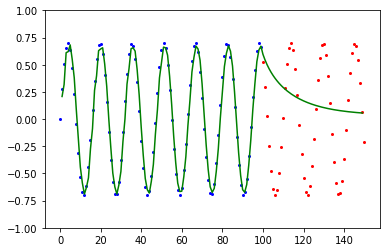

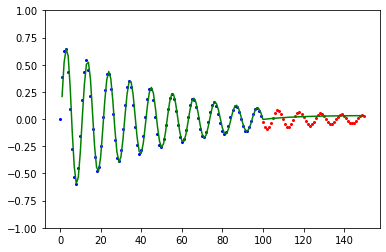

39200 0.008461874917046593 0.1743420759223671


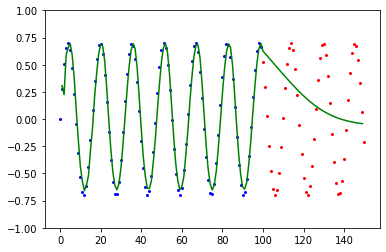

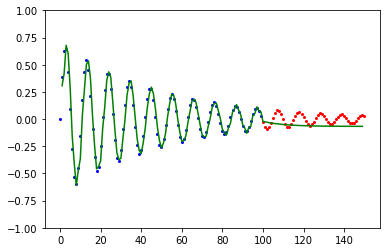

43500 0.007084564441722431 0.1798632761217894


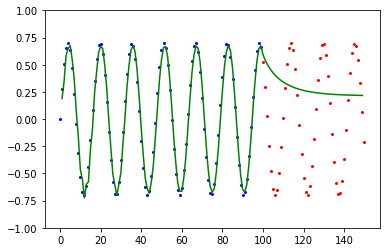

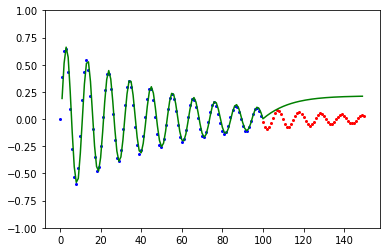

47800 0.007165241911078113 0.16921413508827865


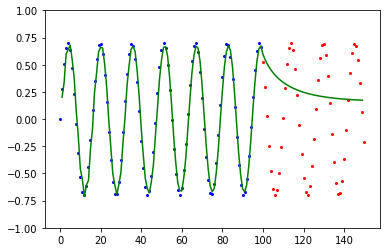

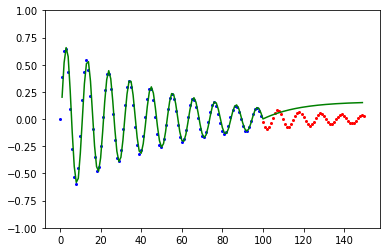

51900 0.00722296249764498 0.1616098352696407


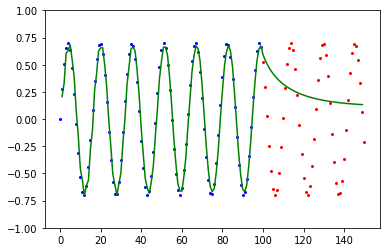

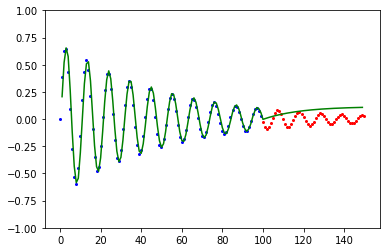

56200 0.0072907518369790085 0.1578603784732862


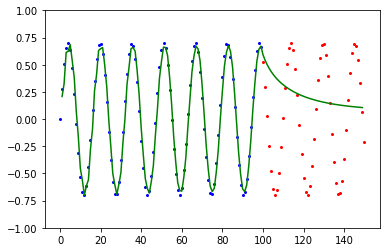

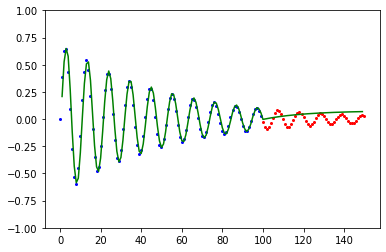

60300 0.007262532993093313 0.16033954332820277


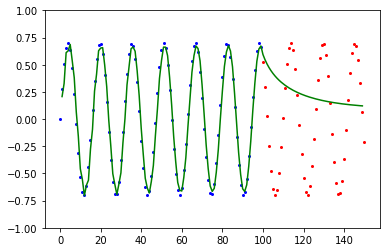

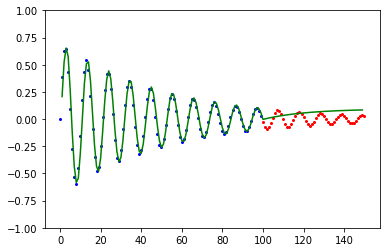

64400 0.007385170746026616 0.15960516274232414


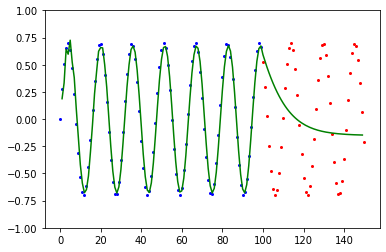

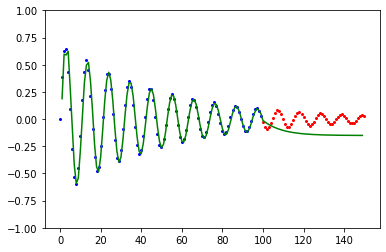

69400 0.007225298877388804 0.1604270637840233


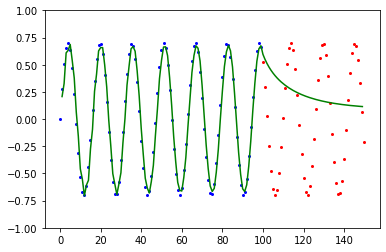

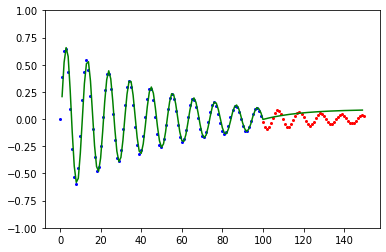

73400 0.007290075033880545 0.15663149293457035


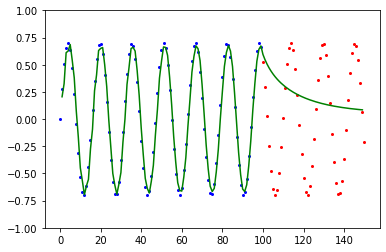

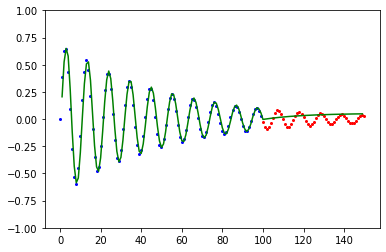

77100 0.007116306215308712 0.18034989903589413


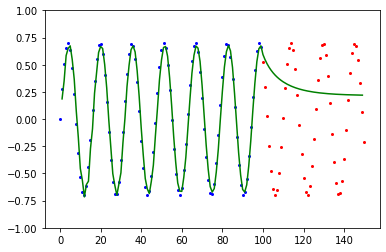

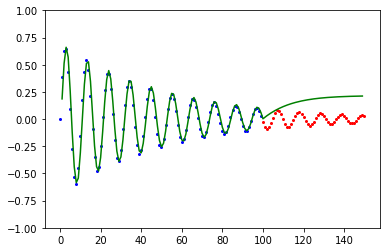

81800 0.007139939554211736 0.17906450607017538


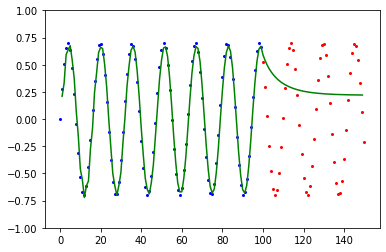

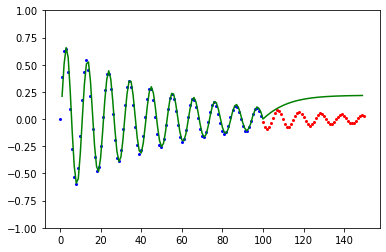

84600 0.0073010113081374865 0.1567115999766002


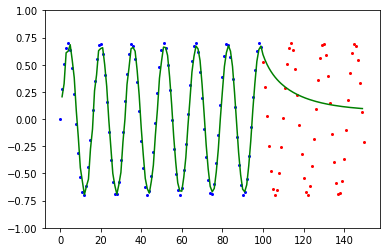

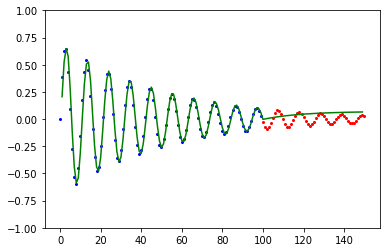

88000 0.0073004346050395495 0.15841410970070563


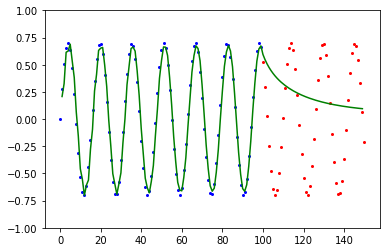

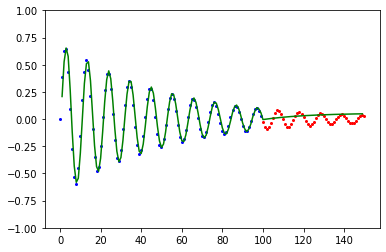

92300 0.007224408593797497 0.16192291879372547


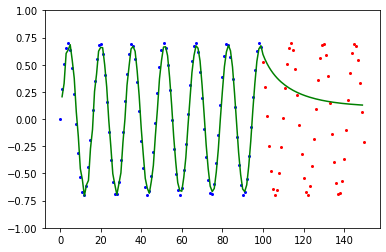

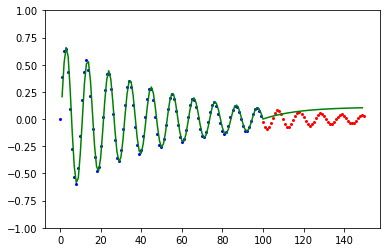

97600 0.0072511347095451685 0.15911911463515307


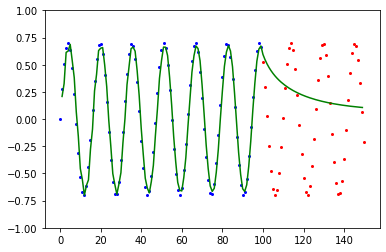

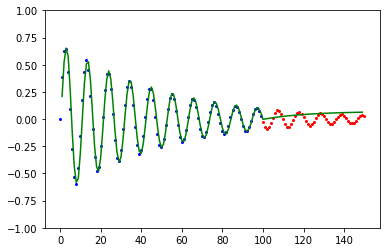

101400 0.007249352656420634 0.1642347317474426


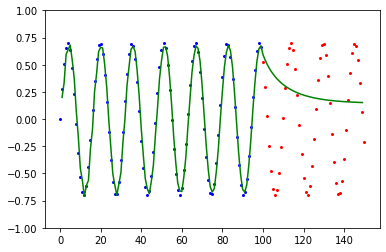

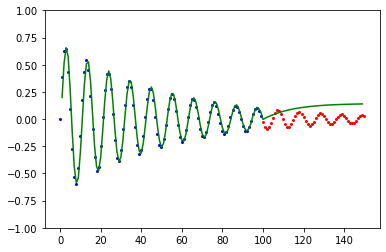

104300 0.007309323527379324 0.1582562240799393


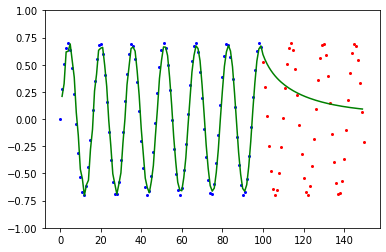

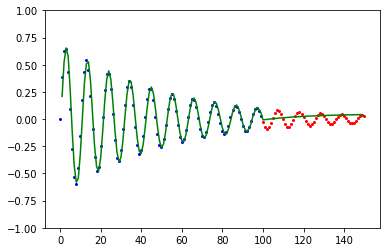

108500 0.007244308277134803 0.16167960772481937


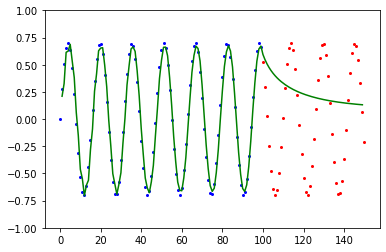

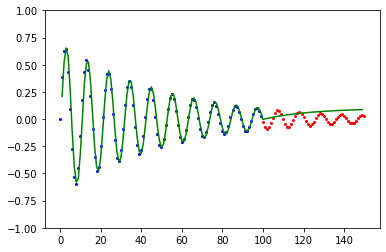

113800 0.007305345607629323 0.1447365925311526


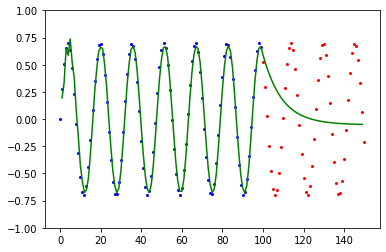

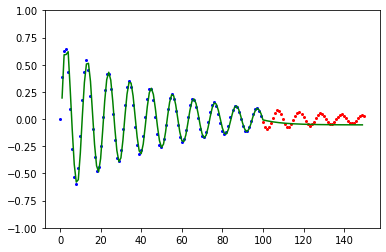

118300 0.007517390774896012 0.14137138398179322


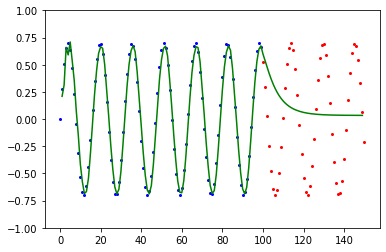

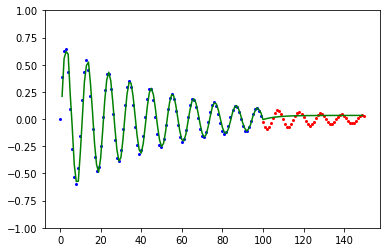

121800 0.007287431495226694 0.1590294201896395


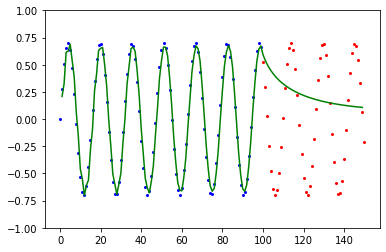

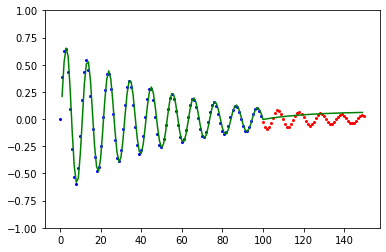

125200 0.007480556038702141 0.14013569345196839


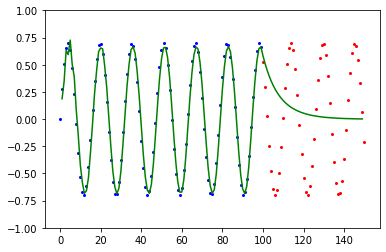

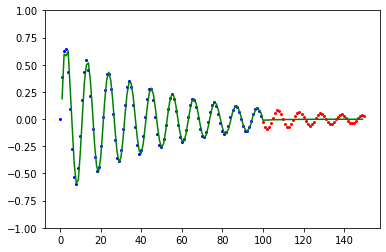

129400 0.007225234299890723 0.15978082372595703


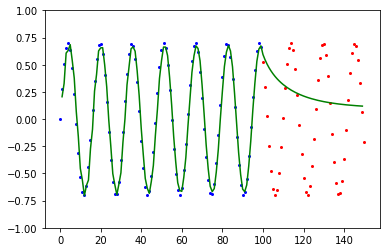

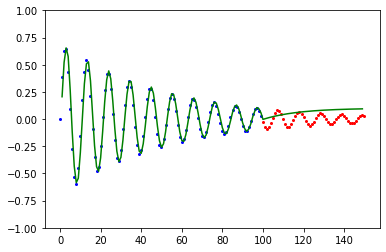

138700 0.007144488510676046 0.16428999968803645


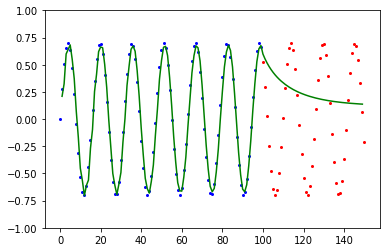

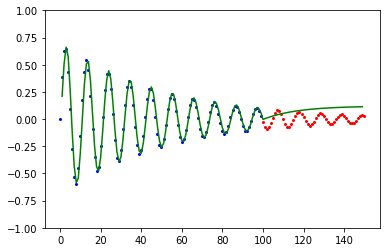

144300 0.007153053988233555 0.17024751813893552


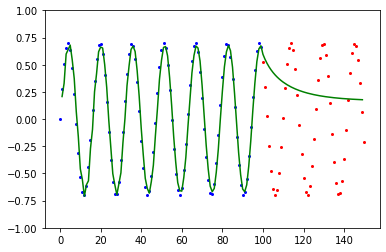

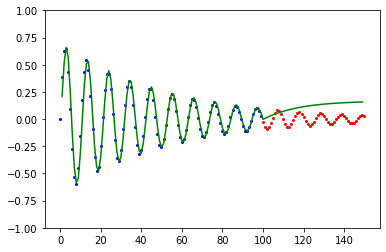

148500 0.007259429557607586 0.14415853479048643


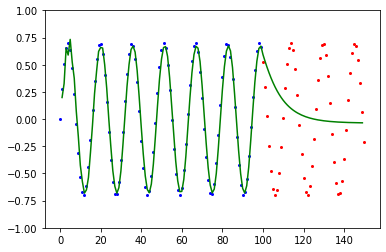

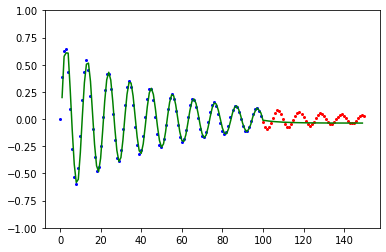

153400 0.007157056500354908 0.16272353324288083


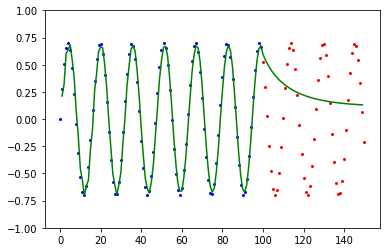

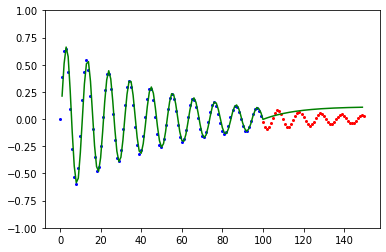

157400 0.0073097121826974955 0.1606841125966146


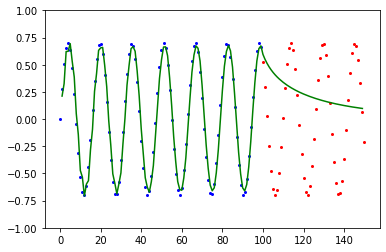

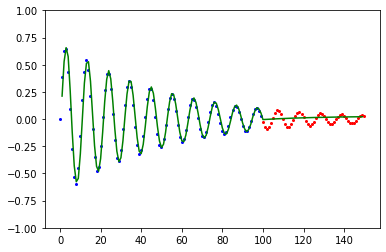

162100 0.0072010720641651465 0.16480832808669563


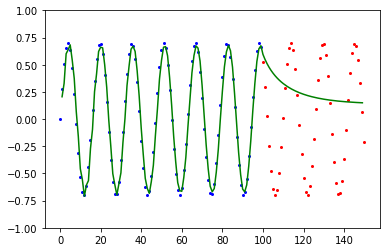

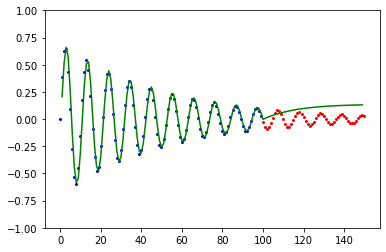

165600 0.007467598177663952 0.14522801009680147


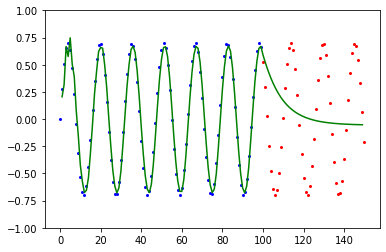

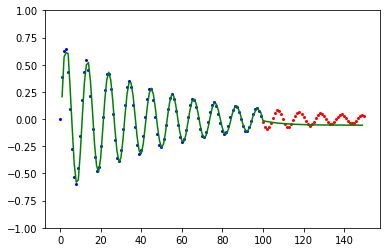

168700 0.007293294583894501 0.15841962056632342


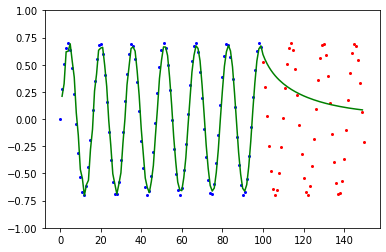

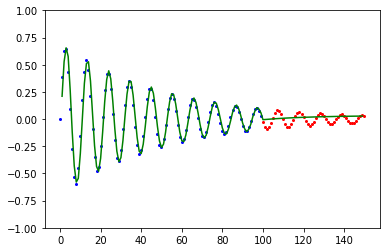

172500 0.007100510275040795 0.17866779233804242


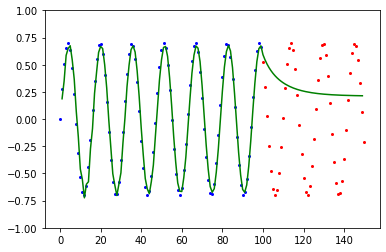

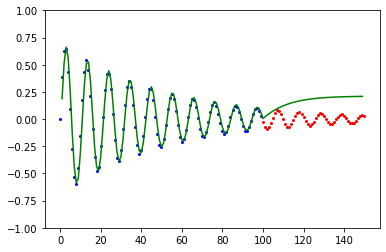

176100 0.007293455088303702 0.15667399722649047


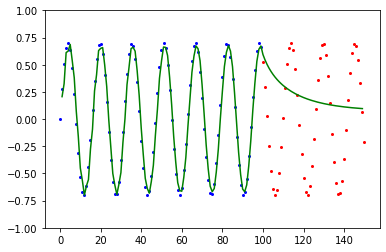

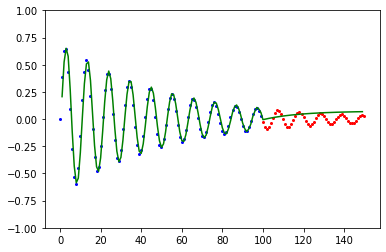

180400 0.007263282836182843 0.16009715281801964


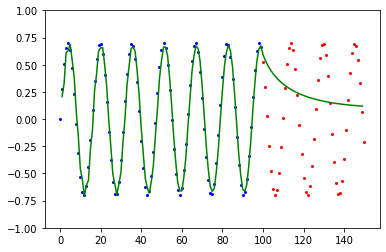

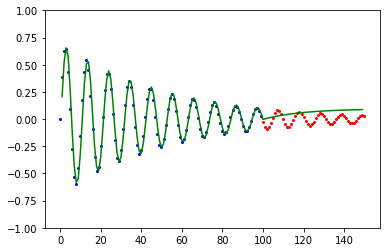

184600 0.0073694207294671766 0.14492430491415698


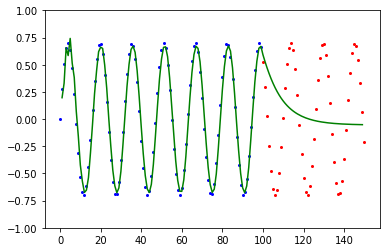

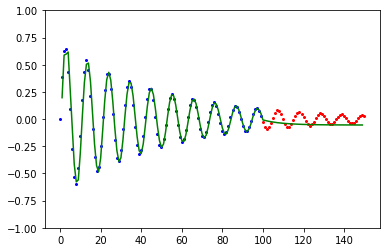

189300 0.007273601053658095 0.1570038902505283


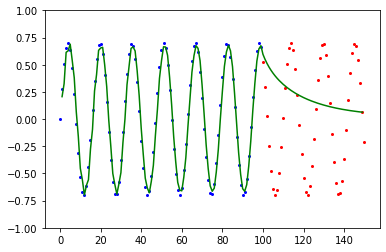

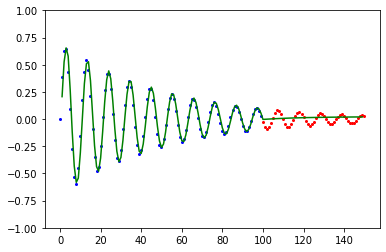

194500 0.007227990694831943 0.1573296683330946


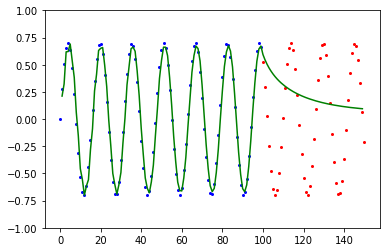

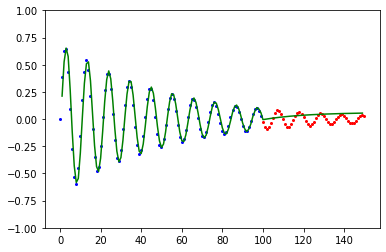

196200 0.007546569807389801 0.15021031738245932


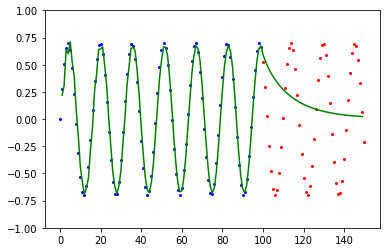

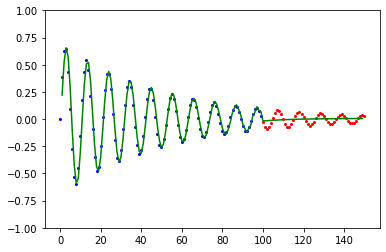

200500 0.0073005920993141 0.156368784083088


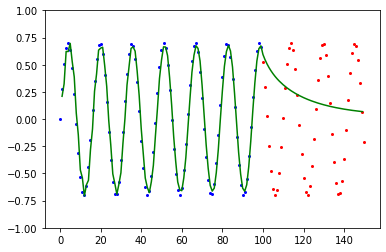

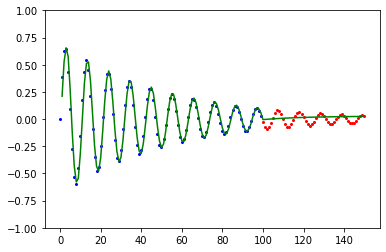

203800 0.0072345644863900365 0.15969197308533076


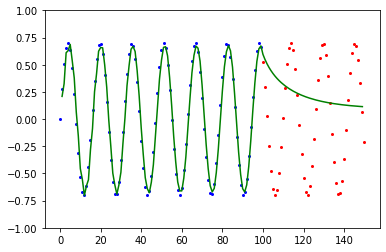

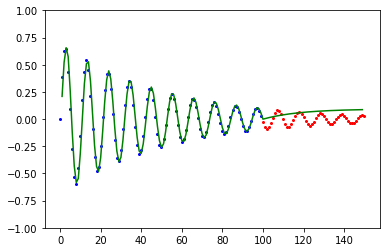

207400 0.007164296575927041 0.1778447443058385


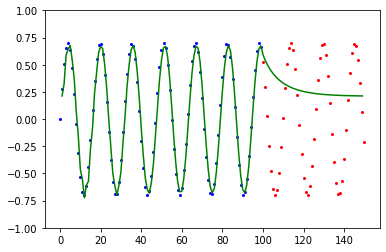

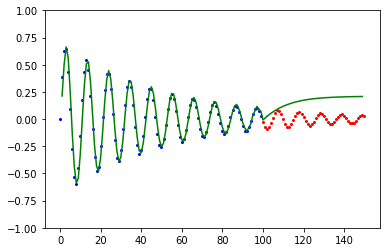

212200 0.00726471950057332 0.15929622176936875


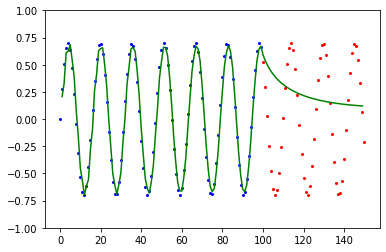

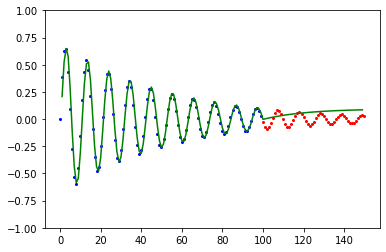

In [33]:
print('best:', test_result[min_idx][0:3])
for pak in test_result:
    i, i_loss, t_loss, _, ys = pak
    print(i, i_loss, t_loss)
    for idx in [0, 1]:
        plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
        plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
        plt.plot(jnp.array(range(len(ys[idx])))+1, ys[idx], c='g')
        plt.ylim(-1,1)
        plt.show()

In [34]:
sum([_[2] for _ in test_result])/len(test_result)

Array(0.16156585, dtype=float64)

In [35]:
len(test_result)

50